In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("animal_features_extended.csv")

In [3]:
# Create encoder
le = LabelEncoder()

# Encode each object/string column
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

#features and values
X=df.iloc[:,:-1]
y=df.iloc[:,[-1]]

#data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

In [4]:
X_train

,EarShape,FaceShape,Whiskers,FurLength,BodySize,Tail,DietType
1,2,2,1,1,2,1,0
15,2,2,1,0,0,1,0
8,1,1,0,1,2,0,1
3,2,2,1,0,1,1,0
9,1,1,0,0,2,0,1
12,2,0,0,0,0,1,1
5,0,2,0,1,0,1,2
6,0,1,0,0,0,1,2
11,2,0,0,1,0,1,1
14,2,1,1,0,0,1,0


In [5]:
def information_gain(X_train, y_train, f_name):
    n_decision = sorted(X_train[f_name].unique())
    x_csvs_branch = []
    y_csvs_branch = []
    
    total = len(y_train)
    left_u = y_train["Animal"].unique()
    n_probs = []
    for n_class in left_u:
        p1 = (y_train[y_train["Animal"]==n_class].count().values[0]) / total
        n_probs.append(p1) 
    n_probs = np.array(n_probs)
    H_root = np.sum(-n_probs*np.log2(n_probs))
    
    H_dn = 0
    
    for n_branch in n_decision:
        
        left_b_x = X_train[X_train[f_name]==n_branch]
        left_b_y = y_train[X_train[f_name]==n_branch]
        x_csvs_branch.append(left_b_x)
        y_csvs_branch.append(left_b_y)
        left_m = len(left_b_x)
        left_u = left_b_y["Animal"].unique()
        n_probs = []
        for n_class in left_u:
            p1 = (left_b_y[left_b_y["Animal"]==n_class].count().values[0]) / left_m
            n_probs.append(p1)
            
        n_probs = np.array(n_probs)
        H_dn = H_dn + len(left_b_y)/total * np.sum(-n_probs*np.log2(n_probs))

    return H_root-H_dn, x_csvs_branch, y_csvs_branch, n_decision

In [6]:
number_classes = len(y_train["Animal"].unique())
depth = 10

IG_value = -np.inf
best_feature = None
best_x_csvs_branchs, best_y_csvs_branchs = [X_train], [y_train]

tree = {}##################
root_node = []
for d in range(depth):
    next_x_branches = []
    next_y_branches = []
    
    for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
        IG_value = -np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        decision = None
        y_pred = None
        for f_name in X_train.columns:
            IG, x_csvs_branch, y_csvs_branch, n_decision = information_gain(best_x_csvs_branch, best_y_csvs_branch, f_name) 
            print("IG",IG)
            if IG>IG_value:
                IG_value = IG
                if IG_value>0:
                    temp_best_x_csvs_branch = x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    best_feature = f_name
                    decision = n_decision
                else:
                    y_pred = le.inverse_transform(y_csvs_branch[0]["Animal"].unique())[0]
        print(best_feature, IG_value, decision)

        node_id = id(best_x_csvs_branch)##################
        root_node.append(node_id)
        tree[node_id] = {             ###################
            "feature": best_feature,
            "ig": IG_value,
            "children": {},
            "pred": y_pred
        } #####################################
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x, decision_name in zip(temp_best_x_csvs_branch, decision): ###########
                tree[node_id]["children"][decision_name] = id(child_x)    ###########
            
    best_x_csvs_branchs = next_x_branches
    best_y_csvs_branchs = next_y_branches
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
            y_pred_class_idx = best_y_csvs_branch["Animal"].value_counts().idxmax() 
            y_pred = le.inverse_transform(np.array([y_pred_class_idx]))[0]
            node_id = id(best_x_csvs_branch)##################
            tree[node_id] = {             ###################
                "feature": None,
                "ig": None,
                "children": {},
                "pred": y_pred
            } #####################################

IG 1.3709505944546687
IG 1.121928094887362
IG 0.9709505944546686
IG 0.17095059445466854
IG 1.0954618442383217
IG 0.7219280948873621
IG 1.5219280948873621
DietType 1.5219280948873621 [np.int64(0), np.int64(1), np.int64(2)]
IG 0.0
IG 0.31127812445913283
IG 0.0
IG 0.31127812445913283
IG 1.0
IG 0.0
IG 0.0
BodySize 1.0 [np.int64(0), np.int64(1), np.int64(2)]
IG 1.0
IG 1.0
IG 0.0
IG 0.0
IG 1.0
IG 1.0
IG 0.0
EarShape 1.0 [np.int64(1), np.int64(2)]
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
IG 0.0
None 0.0 None


In [7]:
tree, root_node

({2093993783856: {'feature': 'DietType',
   'ig': np.float64(1.5219280948873621),
   'children': {np.int64(0): 2093994826720,
    np.int64(1): 2093994825376,
    np.int64(2): 2093994826384},
   'pred': None},
  2093994826720: {'feature': 'BodySize',
   'ig': np.float64(1.0),
   'children': {np.int64(0): 2093994823248,
    np.int64(1): 2093994827280,
    np.int64(2): 2093994827728},
   'pred': 'Cat'},
  2093994825376: {'feature': 'EarShape',
   'ig': np.float64(1.0),
   'children': {np.int64(1): 2093994821232, np.int64(2): 2093994825600},
   'pred': None},
  2093994826384: {'feature': None,
   'ig': np.float64(0.0),
   'children': {},
   'pred': 'Dog'},
  2093994823248: {'feature': None,
   'ig': np.float64(0.0),
   'children': {},
   'pred': 'Lion'},
  2093994827280: {'feature': None,
   'ig': np.float64(0.0),
   'children': {},
   'pred': 'Cat'},
  2093994827728: {'feature': None,
   'ig': np.float64(0.0),
   'children': {},
   'pred': 'Cat'},
  2093994821232: {'feature': None,
   'ig

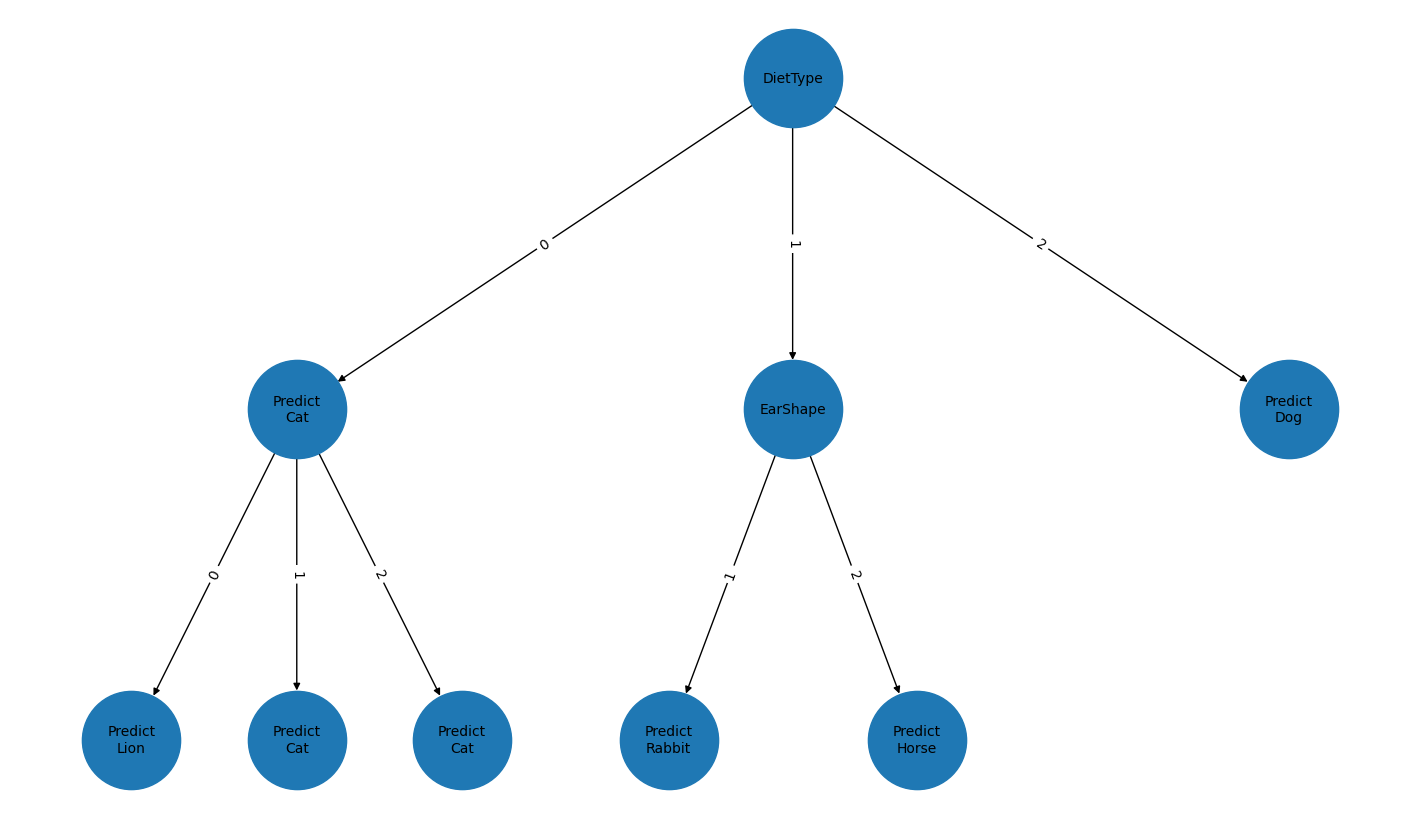

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# Create graph
# =========================

G = nx.DiGraph()

for node_id, info in tree.items():

    # Internal node
    if info["pred"] is not None:
        label = f"Predict\n{info['pred']}"

    # Leaf node
    else:
        label = info["feature"]

    G.add_node(node_id, label=label)

    for decision, child_id in info["children"].items():
        G.add_edge(node_id, child_id, label=str(decision))


# =========================
# Tree layout
# =========================

def hierarchy_pos(G, root, width=1.0, vert_gap=0.2,
                  vert_loc=0, xcenter=0.5):

    pos = {root: (xcenter, vert_loc)}

    children = list(G.successors(root))

    if len(children):

        dx = width / len(children)

        nextx = xcenter - width/2 + dx/2

        for child in children:

            pos.update(
                hierarchy_pos(
                    G,
                    child,
                    width=dx,
                    vert_gap=vert_gap,
                    vert_loc=vert_loc-vert_gap,
                    xcenter=nextx
                )
            )

            nextx += dx

    return pos


# =========================
# Root node
# =========================

root = list(tree.keys())[0]

pos = hierarchy_pos(G, root)

# =========================
# Labels
# =========================

node_labels = nx.get_node_attributes(G, "label")

edge_labels = nx.get_edge_attributes(G, "label")

# =========================
# Draw
# =========================

plt.figure(figsize=(14,8))

nx.draw(
    G,
    pos,
    labels=node_labels,
    with_labels=True,
    node_size=5000,
    font_size=10
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10
)

plt.axis("off")
plt.show()

In [9]:
y_pred = []
for i in range(len(X_test)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search:
            feature_name = list(X_test.columns).index(search)
            value=X_test.iloc[i,feature_name]
            nid = tree[nid]["children"][value]
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = le.inverse_transform(y_test["Animal"].values)

accuracy = np.mean(y_true_labels == y_pred) * 100
accuracy

np.float64(100.0)